# Snapshot Cache Growth Study

This notebook now reproduces the heavy snapshot-cache stress test *and* plots
how the snapshot repository evolves across many churn cycles. It still writes
~100 MB of synthetic test artifacts but performs a long sequence of adds,
deletes, and modifications to mimic noisy suites. Run the cells top-to-bottom to
collect before/after measurements, then study the visual summaries directly in
the notebook.


In [1]:
from __future__ import annotations

import json
import math
import os
import random
import shutil
import subprocess
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from fast_tcp import snapshot_cache

PROJECT_ROOT = Path("..").resolve()
RESEARCH_ROOT = Path(".").resolve()
PLAYGROUND_ROOT = RESEARCH_ROOT / "snapshot_cache_playground"
SUITE_DIR = PLAYGROUND_ROOT / "tests"
DELTA_DIR = SUITE_DIR / "delta"

TARGET_SUITE_MB = 100
FILE_CHUNK_MB = 2
FILE_CHUNK_BYTES = FILE_CHUNK_MB * 1024 * 1024
BASE_FILE_COUNT = TARGET_SUITE_MB // FILE_CHUNK_MB

ITERATIONS = 40
MODIFY_RANGE: Tuple[int, int] = (18, 32)
DELTA_ADDITION_RANGE: Tuple[int, int] = (2, 6)
DELTA_FILE_TTL = 6
DELTA_FILE_SIZES = [FILE_CHUNK_BYTES // 4, FILE_CHUNK_BYTES // 2]

DELTA_REGISTRY: Dict[Path, int] = {}

print(f"Project root: {PROJECT_ROOT}")
print(f"Playground root: {PLAYGROUND_ROOT}")
print(f"Base file count: {BASE_FILE_COUNT}, chunk size: {FILE_CHUNK_MB} MB")
print(f"Iterations configured: {ITERATIONS}, modify range: {MODIFY_RANGE}")
print(
    f"Delta payloads per iter: {DELTA_ADDITION_RANGE[0]}-{DELTA_ADDITION_RANGE[1]}, TTL {DELTA_FILE_TTL}"
)


Project root: /Users/tiagol./Documents/FAST
Playground root: /Users/tiagol./Documents/FAST/research/snapshot_cache_playground
Base file count: 50, chunk size: 2 MB
Iterations configured: 40, modify range: (18, 32)
Delta payloads per iter: 2-6, TTL 6


In [2]:
random.seed(42)

@dataclass
class SnapshotRecord:
    iteration: int
    tag: str
    added: int
    modified: int
    deleted: int
    repo_size_bytes: int
    loose_objects: int
    working_set_bytes: int


def format_bytes(num: int) -> str:
    if num <= 0:
        return "0 B"
    units = ["B", "KiB", "MiB", "GiB", "TiB"]
    current = float(num)
    for unit in units:
        if current < 1024 or unit == units[-1]:
            return f"{current:0.1f} {unit}"
        current /= 1024
    return f"{current:0.1f} PiB"


def ensure_playground_clean() -> None:
    if PLAYGROUND_ROOT.exists():
        shutil.rmtree(PLAYGROUND_ROOT)
    SUITE_DIR.mkdir(parents=True, exist_ok=True)
    DELTA_REGISTRY.clear()


def write_payload(path: Path, label: str, size_bytes: int = FILE_CHUNK_BYTES) -> None:
    block = (label.encode("utf-8") + b"|")
    repeats = (size_bytes // len(block)) + 1
    payload = (block * repeats)[:size_bytes]
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_bytes(payload)


def seed_suite() -> None:
    for idx in range(BASE_FILE_COUNT):
        target = SUITE_DIR / f"test_chunk_{idx:04d}.bin"
        write_payload(target, f"seed-{idx}")


def working_set_bytes() -> int:
    total = 0
    for path in PLAYGROUND_ROOT.rglob("*"):
        if path.is_file() and ".fast" not in path.parts:
            total += path.stat().st_size
    return total


def snapshot_repo_path() -> Path:
    return PLAYGROUND_ROOT / ".fast" / "snapshot.git"


def snapshot_repo_size_bytes() -> int:
    repo = snapshot_repo_path()
    if not repo.exists():
        return 0
    return sum(p.stat().st_size for p in repo.rglob("*") if p.is_file())


def git_stats() -> Dict[str, int]:
    repo = snapshot_repo_path()
    if not repo.exists():
        return {"count": 0, "size_bytes": 0}
    env = os.environ.copy()
    env["GIT_DIR"] = str(repo)
    proc = subprocess.run(
        ["git", "count-objects", "-v"],
        cwd=PLAYGROUND_ROOT,
        env=env,
        capture_output=True,
        text=True,
        check=True,
    )
    stats: Dict[str, int] = {}
    for line in proc.stdout.splitlines():
        if ":" not in line:
            continue
        key, value = line.split(":", 1)
        try:
            stats[key.strip()] = int(value.strip().split()[0])
        except ValueError:
            continue
    stats["size_bytes"] = snapshot_repo_size_bytes()
    return stats


def age_delta_files() -> int:
    """Decrease TTL for adhoc files and delete those that expired."""
    expired = 0
    for path in list(DELTA_REGISTRY.keys()):
        DELTA_REGISTRY[path] -= 1
        if DELTA_REGISTRY[path] <= 0:
            if path.exists():
                path.unlink()
            expired += 1
            DELTA_REGISTRY.pop(path, None)
    return expired


def mutate_suite(iteration: int) -> Dict[str, int]:
    min_mod, max_mod = MODIFY_RANGE
    max_mod = min(max_mod, BASE_FILE_COUNT)
    min_mod = min(min_mod, max_mod)
    modifications = random.randint(min_mod, max_mod)
    indices = random.sample(range(BASE_FILE_COUNT), modifications)
    for idx in indices:
        path = SUITE_DIR / f"test_chunk_{idx:04d}.bin"
        write_payload(path, f"iter-{iteration}-file-{idx}")

    expired = age_delta_files()

    additions = random.randint(*DELTA_ADDITION_RANGE)
    DELTA_DIR.mkdir(parents=True, exist_ok=True)
    for add_idx in range(additions):
        size_bytes = random.choice(DELTA_FILE_SIZES)
        salt = random.randint(0, 9999)
        extra_path = DELTA_DIR / f"iter_{iteration:04d}_{add_idx:02d}_{salt:04d}.bin"
        write_payload(extra_path, f"delta-{iteration}-{add_idx}", size_bytes=size_bytes)
        DELTA_REGISTRY[extra_path] = DELTA_FILE_TTL

    return {
        "modified": modifications,
        "delta_added": additions,
        "delta_expired": expired,
    }


def run_snapshot_cycle(iteration: int, tag: str) -> SnapshotRecord:
    diff = snapshot_cache.detect_changes_preparation(PLAYGROUND_ROOT)
    snapshot_cache.snapshot_prioritization(PLAYGROUND_ROOT)
    stats = git_stats()
    record = SnapshotRecord(
        iteration=iteration,
        tag=tag,
        added=len(diff.added),
        modified=len(diff.modified),
        deleted=len(diff.deleted),
        repo_size_bytes=stats.get("size_bytes", 0),
        loose_objects=stats.get("count", 0),
        working_set_bytes=working_set_bytes(),
    )
    return record



In [3]:
ensure_playground_clean()
seed_suite()
records: List[SnapshotRecord] = []

baseline = run_snapshot_cycle(0, "seed")
records.append(baseline)
print(
    f"Seed snapshot complete -> repo {format_bytes(baseline.repo_size_bytes)}, "
    f"workspace {format_bytes(baseline.working_set_bytes)}"
)



Seed snapshot complete -> repo 180.9 KiB, workspace 100.0 MiB


In [4]:
for iteration in range(1, ITERATIONS + 1):
    mutation_stats = mutate_suite(iteration)
    record = run_snapshot_cycle(iteration, f"iter-{iteration}")
    records.append(record)
    print(
        f"{record.tag:<8} | added {record.added:3d} | "
        f"modified {record.modified:3d} | deleted {record.deleted:3d} | "
        f"repo {format_bytes(record.repo_size_bytes)} | "
        f"workspace {format_bytes(record.working_set_bytes)} | "
        f"loose {record.loose_objects} | "
        f"Δdelta +{mutation_stats['delta_added']:02d}/-{mutation_stats['delta_expired']:02d} "
        f"(~{mutation_stats['modified']:02d} base mods)"
    )

print("\nIterations completed. Total records:", len(records))


iter-1   | added   6 | modified  28 | deleted   0 | repo 218.6 KiB | workspace 104.5 MiB | loose 0 | Δdelta +06/-00 (~28 base mods)
iter-2   | added   2 | modified  19 | deleted   0 | repo 231.8 KiB | workspace 106.0 MiB | loose 0 | Δdelta +02/-00 (~19 base mods)
iter-3   | added   3 | modified  25 | deleted   0 | repo 241.1 KiB | workspace 108.0 MiB | loose 0 | Δdelta +03/-00 (~25 base mods)
iter-4   | added   5 | modified  32 | deleted   0 | repo 254.5 KiB | workspace 112.5 MiB | loose 0 | Δdelta +05/-00 (~32 base mods)
iter-5   | added   5 | modified  19 | deleted   0 | repo 264.0 KiB | workspace 115.5 MiB | loose 0 | Δdelta +05/-00 (~19 base mods)
iter-6   | added   6 | modified  29 | deleted   0 | repo 270.6 KiB | workspace 118.5 MiB | loose 0 | Δdelta +06/-00 (~29 base mods)
iter-7   | added   2 | modified  21 | deleted   6 | repo 264.2 KiB | workspace 115.5 MiB | loose 0 | Δdelta +02/-06 (~21 base mods)
iter-8   | added   3 | modified  30 | deleted   2 | repo 267.3 KiB | workspa

In [5]:
def summarize(records: List[SnapshotRecord]) -> pd.DataFrame:
    df = pd.DataFrame([r.__dict__ for r in records])
    df["repo_size_mb"] = df["repo_size_bytes"] / (1024 ** 2)
    df["workspace_mb"] = df["working_set_bytes"] / (1024 ** 2)
    df["repo_density_pct"] = (
        df["repo_size_bytes"] / df["working_set_bytes"].clip(lower=1)
    ) * 100

    before = df.iloc[0]
    after = df.iloc[-1]
    repo_delta = after.repo_size_bytes - before.repo_size_bytes
    workspace_delta = after.working_set_bytes - before.working_set_bytes
    repo_spread = df["repo_size_bytes"].max() - df["repo_size_bytes"].min()
    workspace_spread = df["working_set_bytes"].max() - df["working_set_bytes"].min()

    summary_md = f"""
**Snapshot Cache Summary**

- Repo size: {format_bytes(before.repo_size_bytes)} → {format_bytes(after.repo_size_bytes)} (Δ {format_bytes(repo_delta)})
- Workspace: {format_bytes(before.working_set_bytes)} → {format_bytes(after.working_set_bytes)} (Δ {format_bytes(workspace_delta)})
- Repo spread: {format_bytes(df['repo_size_bytes'].min())} – {format_bytes(df['repo_size_bytes'].max())} (Δ {format_bytes(repo_spread)})
- Workspace spread: {format_bytes(df['working_set_bytes'].min())} – {format_bytes(df['working_set_bytes'].max())} (Δ {format_bytes(workspace_spread)})
- Iterations sampled: {len(df)}
"""

    display(Markdown(summary_md))
    return df


history_df = summarize(records)




**Snapshot Cache Summary**

- Repo size: 180.9 KiB → 262.0 KiB (Δ 81.1 KiB)
- Workspace: 100.0 MiB → 114.5 MiB (Δ 14.5 MiB)
- Repo spread: 180.9 KiB – 276.8 KiB (Δ 95.9 KiB)
- Workspace spread: 100.0 MiB – 121.5 MiB (Δ 21.5 MiB)
- Iterations sampled: 41


In [6]:
display(Markdown("### Snapshot Records (last 12 iterations)"))
preview_cols = [
    "iteration",
    "repo_size_mb",
    "workspace_mb",
    "added",
    "modified",
    "deleted",
    "loose_objects",
]
display(history_df[preview_cols].tail(12).round({"repo_size_mb": 2, "workspace_mb": 2}))



### Snapshot Records (last 12 iterations)

,iteration,repo_size_mb,workspace_mb,added,modified,deleted,loose_objects
29,29,0.26,115.0,2,26,2,0
30,30,0.26,117.5,5,29,3,0
31,31,0.26,117.5,3,24,3,0
32,32,0.26,117.5,3,31,3,0
33,33,0.26,117.5,5,27,6,0
34,34,0.26,116.5,2,22,4,0
35,35,0.26,117.5,3,23,2,0
36,36,0.26,116.0,5,22,5,0
37,37,0.26,116.5,3,20,3,0
38,38,0.26,116.5,3,24,3,0


### Snapshot Cache Visuals

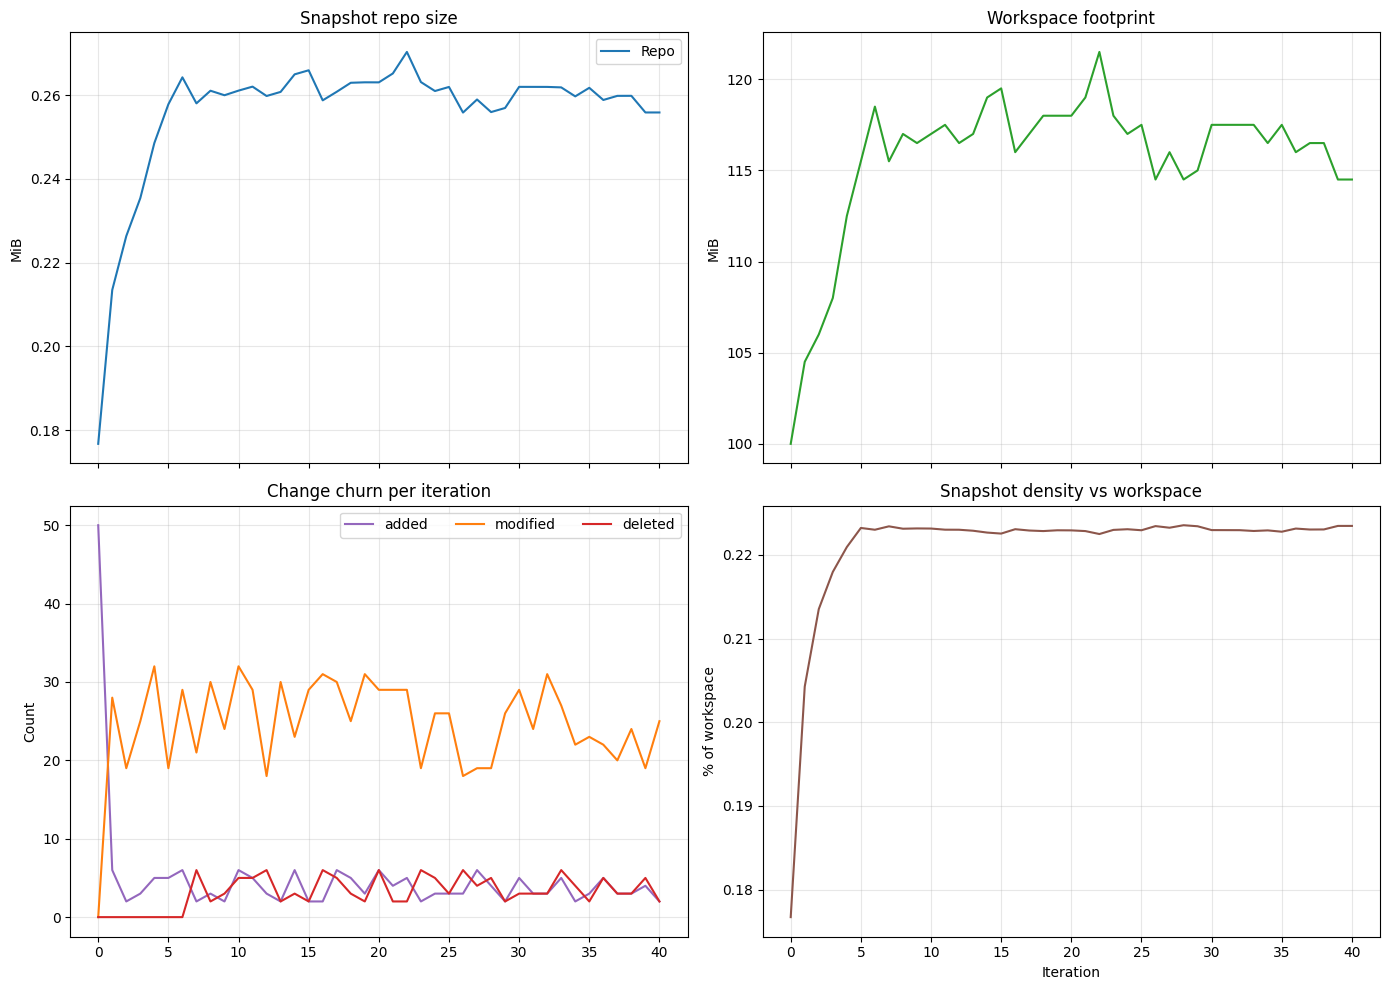

In [7]:
display(Markdown("### Snapshot Cache Visuals"))
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
iterations = history_df["iteration"]

axes[0, 0].plot(iterations, history_df["repo_size_mb"], color="tab:blue", label="Repo")
axes[0, 0].set_ylabel("MiB")
axes[0, 0].set_title("Snapshot repo size")
axes[0, 0].legend()

axes[0, 1].plot(iterations, history_df["workspace_mb"], color="tab:green")
axes[0, 1].set_ylabel("MiB")
axes[0, 1].set_title("Workspace footprint")

axes[1, 0].plot(iterations, history_df["added"], label="added", color="tab:purple", linewidth=1.5)
axes[1, 0].plot(iterations, history_df["modified"], label="modified", color="tab:orange", linewidth=1.5)
axes[1, 0].plot(iterations, history_df["deleted"], label="deleted", color="tab:red", linewidth=1.5)
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_title("Change churn per iteration")
axes[1, 0].legend(loc="upper right", ncol=3)

axes[1, 1].plot(iterations, history_df["repo_density_pct"], color="tab:brown")
axes[1, 1].set_ylabel("% of workspace")
axes[1, 1].set_title("Snapshot density vs workspace")
axes[1, 1].set_xlabel("Iteration")

for ax in axes.flat:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()



In [8]:
SAVE_RECORDS = False  # Flip to True if you want to persist the raw numbers
output_path = PLAYGROUND_ROOT / "snapshot_records.json"

if SAVE_RECORDS:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_path.write_text(
        json.dumps([r.__dict__ for r in records], indent=2),
        encoding="utf-8",
    )
    print("Saved run summary to", output_path)
else:
    print("Skipping JSON export (set SAVE_RECORDS=True to persist this run).")



Skipping JSON export (set SAVE_RECORDS=True to persist this run).


## Cleanup

Rerun the `ensure_playground_clean()` helper (or simply delete the
`snapshot_cache_playground/` folder) after collecting the data if you do not need
the generated artifacts anymore.
